# Rule Prevalence and Network


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

file_path = "/Users/RaulPerez/Documents/Projects/cumulative_report/data/raw/country_year_final_panel_full_new.csv"
df = pd.read_csv(file_path)

rule_prefixes = (
    "C_", "I_", "P_",
    "IM_", "GOV_", "PRESS_",
    "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"
)

value_cols = [c for c in df.columns if str(c).startswith(rule_prefixes)]

id_cols = [c for c in df.columns if c in ["COUNTRY", "year", "iso3"] or str(c).startswith("Unnamed")]

X_presence = (df[value_cols].fillna(0) != 0).astype(int)

# Use the _new panel's authoritative weighted measures under the old
# analysis column names so the existing EDA code runs unchanged.
weighted_aliases = {
    "de_jure": "dj_expression",
    "weighted_de_jure": "wdj_expression",
    "weighted_de_jure_C": "wdj_citizen",
    "weighted_de_jure_I": "wdj_intermediaries",
    "weighted_de_jure_P": "wdj_press",
    "weighted_de_jure_GOV.PROT": "wdj_govprot",
    "weighted_de_jure_RESTRICTION": "wdj_restriction",
    "weighted_de_jure_OBLIGATION": "wdj_obligation",
}

for target, source in weighted_aliases.items():
    if target not in df.columns and source in df.columns:
        df[target] = df[source]

if "legal_rule_count_total" not in df.columns:
    df["legal_rule_count_total"] = X_presence.sum(axis=1)

if "legal_rule_count_RESTRICTION" not in df.columns:
    restriction_cols = [c for c in value_cols if "_EXPRESS_" in c]
    df["legal_rule_count_RESTRICTION"] = X_presence[restriction_cols].sum(axis=1)

if "legal_rule_count_OBLIGATION" not in df.columns:
    obligation_cols = [
        c for c in value_cols
        if c.startswith(("IM_", "GOV_", "PRESS_", "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"))
    ]
    df["legal_rule_count_OBLIGATION"] = X_presence[obligation_cols].sum(axis=1)


print("Dataset shape:", df.shape)
print("Number of rule columns:", len(value_cols))
print("First 10 rule columns:", value_cols[:10])

Dataset shape: (8580, 753)
Number of rule columns: 730
First 10 rule columns: ['C_DISINFO_GEN', 'I_DISINFO_GEN', 'P_DISINFO_GEN', 'C_DISINFO_GEN_DIGI', 'I_DISINFO_GEN_DIGI', 'P_DISINFO_GEN_DIGI', 'C_DISINFO_GEN_CRISIS', 'I_DISINFO_GEN_CRISIS', 'P_DISINFO_GEN_CRISIS', 'C_MALINFO_GEN']


## Column Classification


In [61]:
def classify_scope(col):
    tokens = str(col).split("_")
    family = tokens[0]

    out = {
        "column": col,
        "family": family,
        "scope_group": None,
        "actor_group": None,
        "topic": None,
        "basis": None,
        "condition": "standard",
        "detail": None,
    }

    if family in {"C", "I", "P"}:
        out["scope_group"] = "substantive_regulation"
    elif family in {"IM", "GOV", "PRESS"}:
        out["scope_group"] = "governance_design"
    elif family in {"APPEAL", "EXEMPTION", "LAWSUIT", "REG"}:
        out["scope_group"] = "procedural_protection"
    else:
        out["scope_group"] = "other"

    actor_map = {
        "C": "citizens",
        "I": "internet/platforms",
        "P": "press",
        "IM": "intermediary_design",
        "GOV": "government_design",
        "PRESS": "press_design",
        "APPEAL": "procedural",
        "EXEMPTION": "procedural",
        "LAWSUIT": "procedural",
        "REG": "procedural",
    }
    out["actor_group"] = actor_map.get(family, "other")

    if "NON-ICCPR" in tokens:
        out["basis"] = "NON-ICCPR"
    elif "ICCPR" in tokens:
        out["basis"] = "ICCPR"
    elif "GEN" in tokens:
        out["basis"] = "GEN"

    conds = [t for t in tokens if t in {"CRISIS", "DIGI", "GOVOFF"}]
    if conds:
        out["condition"] = "|".join(conds)

    if family in {"C", "I", "P"}:
        if "DISINFO" in tokens:
            out["topic"] = "disinformation"
        elif "MISINFO" in tokens:
            out["topic"] = "misinformation"
        elif "MALINFO" in tokens:
            out["topic"] = "malinformation"
        elif "EXPRESS" in tokens:
            out["topic"] = "restriction"
    elif family == "IM":
        out["topic"] = "intermediary_obligation"
        out["detail"] = "_".join(tokens[1:])
    elif family == "GOV":
        out["topic"] = "government_power"
        out["detail"] = "_".join(tokens[1:])
    elif family == "PRESS":
        out["topic"] = "press_obligation"
        out["detail"] = "_".join(tokens[1:])
    elif family == "APPEAL":
        out["topic"] = "appeal"
        out["detail"] = "_".join(tokens[1:])
    elif family == "EXEMPTION":
        out["topic"] = "exemption"
        out["detail"] = "_".join(tokens[1:])
    elif family == "LAWSUIT":
        out["topic"] = "lawsuit"
        out["detail"] = "_".join(tokens[1:])
    elif family == "REG":
        out["topic"] = "regulation"
        out["detail"] = "_".join(tokens[1:])

    return out

col_dict = pd.DataFrame([classify_scope(c) for c in value_cols])

print(col_dict.head())

               column family             scope_group         actor_group  \
0       C_DISINFO_GEN      C  substantive_regulation            citizens   
1       I_DISINFO_GEN      I  substantive_regulation  internet/platforms   
2       P_DISINFO_GEN      P  substantive_regulation               press   
3  C_DISINFO_GEN_DIGI      C  substantive_regulation            citizens   
4  I_DISINFO_GEN_DIGI      I  substantive_regulation  internet/platforms   

            topic basis condition detail  
0  disinformation   GEN  standard   None  
1  disinformation   GEN  standard   None  
2  disinformation   GEN  standard   None  
3  disinformation   GEN      DIGI   None  
4  disinformation   GEN      DIGI   None  


## Rule Prevalence


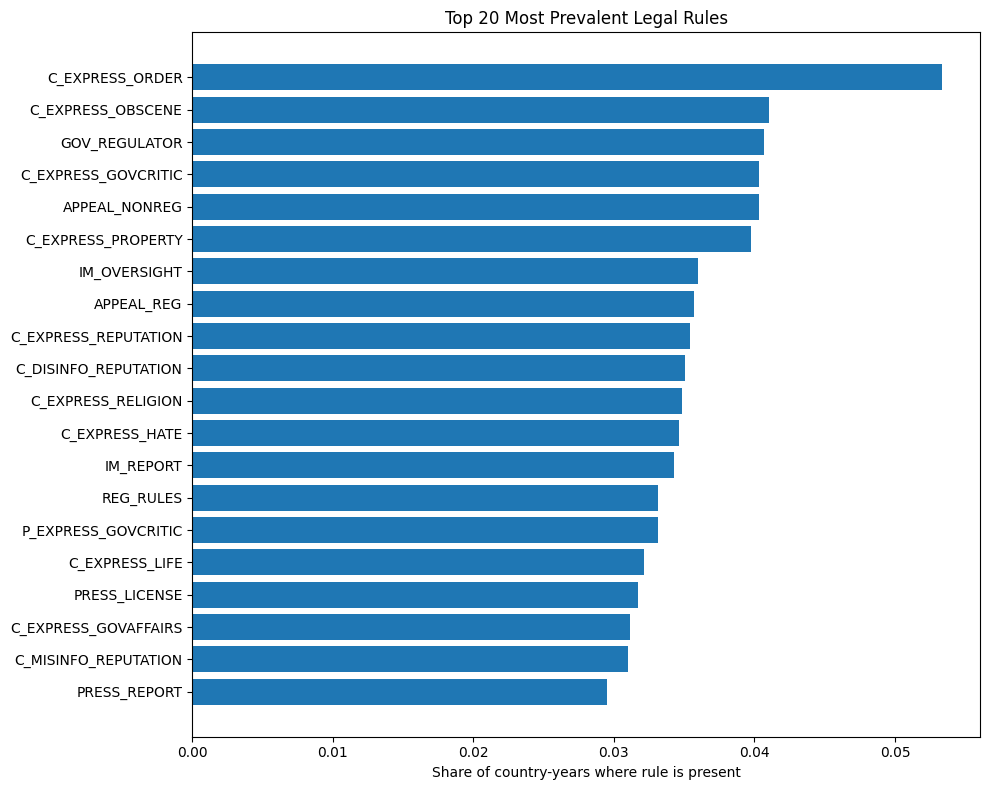

,column,prevalence
718,PRESS_REPORT,0.029487
307,C_MISINFO_REPUTATION,0.031002
469,C_EXPRESS_GOVAFFAIRS,0.031119
714,PRESS_LICENSE,0.031702
144,C_EXPRESS_LIFE,0.032168
480,P_EXPRESS_GOVCRITIC,0.033100
686,REG_RULES,0.033100
708,IM_REPORT,0.034266
126,C_EXPRESS_HATE,0.034615
208,C_EXPRESS_RELIGION,0.034848


In [62]:
presence_summary = pd.DataFrame({
    "column": value_cols,
    "prevalence": X_presence.mean().values
})

top_n = 20

fig1_df = (
    presence_summary
    .sort_values("prevalence", ascending=False)
    .head(top_n)
    .sort_values("prevalence", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(fig1_df["column"], fig1_df["prevalence"])
plt.xlabel("Share of country-years where rule is present")
plt.title("Top 20 Most Prevalent Legal Rules")
plt.tight_layout()
plt.show()

fig1_df

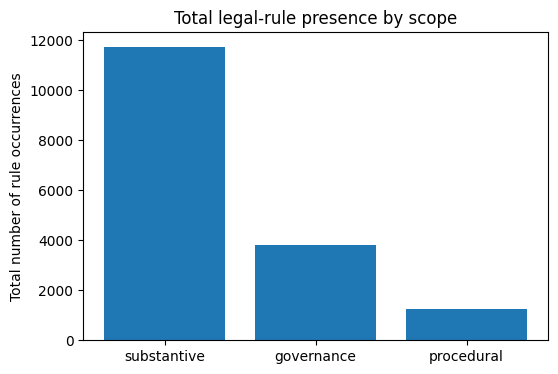

,group,total_presence
0,substantive,11741
1,governance,3797
2,procedural,1253


In [63]:
groups = {
    "substantive": [c for c in value_cols if c.startswith(("C_", "I_", "P_"))],
    "governance": [c for c in value_cols if c.startswith(("IM_", "GOV_", "PRESS_"))],
    "procedural": [c for c in value_cols if c.startswith(("APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"))],
}

total_summary = []

for name, cols in groups.items():
    total_summary.append({
        "group": name,
        "total_presence": X_presence[cols].sum().sum()
    })

total_df = pd.DataFrame(total_summary)

plt.figure(figsize=(6, 4))
plt.bar(total_df["group"], total_df["total_presence"])
plt.ylabel("Total number of rule occurrences")
plt.title("Total legal-rule presence by scope")
plt.show()

total_df

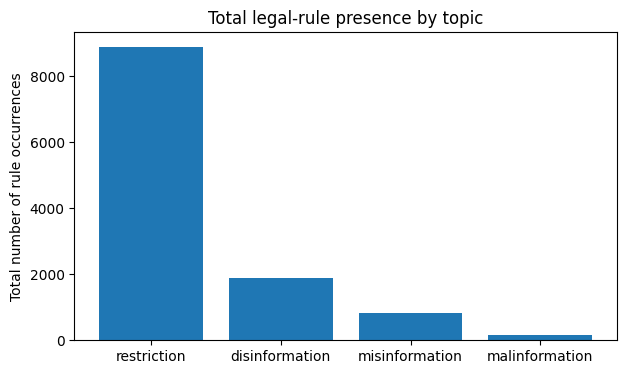

,topic,avg_prevalence,total_presence
0,restriction,0.004408,8887
1,disinformation,0.001011,1873
2,misinformation,0.000447,829
3,malinformation,0.001968,152


In [64]:
topic_groups = {
    "restriction": [c for c in value_cols if "_EXPRESS_" in c],
    "disinformation": [c for c in value_cols if "_DISINFO_" in c],
    "misinformation": [c for c in value_cols if "_MISINFO_" in c],
    "malinformation": [c for c in value_cols if "_MALINFO_" in c],
}

topic_summary = []

for topic, cols in topic_groups.items():
    topic_summary.append({
        "topic": topic,
        "avg_prevalence": X_presence[cols].mean().mean() if len(cols) > 0 else np.nan,
        "total_presence": X_presence[cols].sum().sum() if len(cols) > 0 else 0
    })

topic_df = pd.DataFrame(topic_summary)

plt.figure(figsize=(7, 4))
plt.bar(topic_df["topic"], topic_df["total_presence"])
plt.ylabel("Total number of rule occurrences")
plt.title("Total legal-rule presence by topic")
plt.show()

topic_df

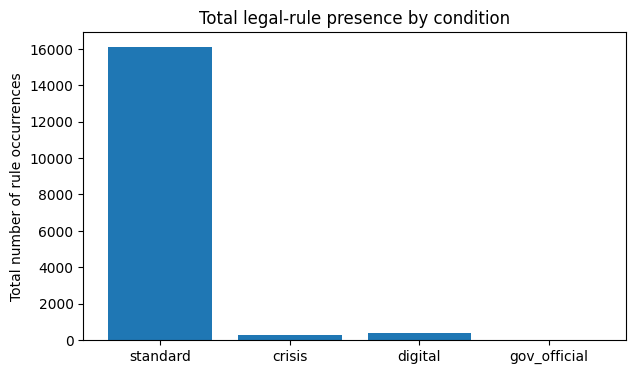

,condition,avg_prevalence,total_presence
0,standard,0.007451,16110
1,crisis,0.000126,273
2,digital,0.000211,408
3,gov_official,0.000000,0


In [65]:
condition_groups = {
    "standard": [c for c in value_cols if not any(tag in c for tag in ["_CRISIS", "_DIGI", "_GOVOFF"])],
    "crisis": [c for c in value_cols if "_CRISIS" in c],
    "digital": [c for c in value_cols if "_DIGI" in c],
    "gov_official": [c for c in value_cols if "_GOVOFF" in c],
}

condition_summary = []

for cond, cols in condition_groups.items():
    if len(cols) == 0:
        continue

    condition_summary.append({
        "condition": cond,
        "avg_prevalence": X_presence[cols].mean().mean(),
        "total_presence": X_presence[cols].sum().sum()
    })

condition_df = pd.DataFrame(condition_summary)

plt.figure(figsize=(7, 4))
plt.bar(condition_df["condition"], condition_df["total_presence"])
plt.ylabel("Total number of rule occurrences")
plt.title("Total legal-rule presence by condition")
plt.show()

condition_df

## Co-occurrence


In [66]:
std_cols = [c for c in value_cols if not any(tag in c for tag in ["_CRISIS", "_DIGI", "_GOVOFF"])]

X_std = X_presence[std_cols].copy()

min_prev = 0.005
keep_cols = X_std.columns[X_std.mean() >= min_prev]
X_std = X_std[keep_cols]

print("Standard-rule columns before filtering:", len(std_cols))
print("Columns kept after rarity filter:", len(keep_cols))

cooccur = X_std.T.dot(X_std)

np.fill_diagonal(cooccur.values, 0)

cooccur_long = (
    cooccur.stack()
    .reset_index()
)
cooccur_long.columns = ["rule_1", "rule_2", "cooccur"]

cooccur_long = cooccur_long[cooccur_long["rule_1"] < cooccur_long["rule_2"]]

top_pairs = cooccur_long.sort_values("cooccur", ascending=False).head(60)

top_pairs.head(60)

Standard-rule columns before filtering: 252
Columns kept after rarity filter: 95


,rule_1,rule_2,cooccur
4873,C_EXPRESS_GOVCRITIC,C_EXPRESS_ORDER,269
2403,C_EXPRESS_OBSCENE,C_EXPRESS_ORDER,260
4706,C_EXPRESS_GOVAFFAIRS,C_EXPRESS_GOVCRITIC,253
4683,C_EXPRESS_GOVAFFAIRS,C_EXPRESS_ORDER,237
1646,C_EXPRESS_LIFE,C_EXPRESS_PROPERTY,232
6914,GOV_REGULATOR,REG_RULES,228
4897,C_EXPRESS_GOVCRITIC,P_EXPRESS_GOVCRITIC,227
2726,C_EXPRESS_ORDER,C_EXPRESS_UNITY,224
7970,IM_LICENSE,IM_REPORT,223
2691,C_EXPRESS_ORDER,C_EXPRESS_PROPERTY,223


## Cutoff Diagnostics


Positive rule pairs: 3272
Elbow cutoff: 95 | edges: 507 | elbow rank: 439
Recommended quantile cutoff: 109 | quantile: 0.9 | edges: 331


,cooccur
count,3272.000000
mean,50.026284
std,41.615584
min,1.000000
50%,40.000000
75%,66.000000
80%,78.000000
85%,95.000000
90%,109.000000
92.5%,122.000000


,quantile,cutoff,edges,nodes,components,largest_component,component_sizes
0,0.900,109,331,48,1,48,[48]
1,0.925,122,249,47,1,47,[47]
2,0.950,139,164,40,2,38,"[38, 2]"
3,0.975,159,82,35,2,32,"[32, 3]"
4,0.990,185,34,25,5,14,"[14, 3, 3, 3, 2]"


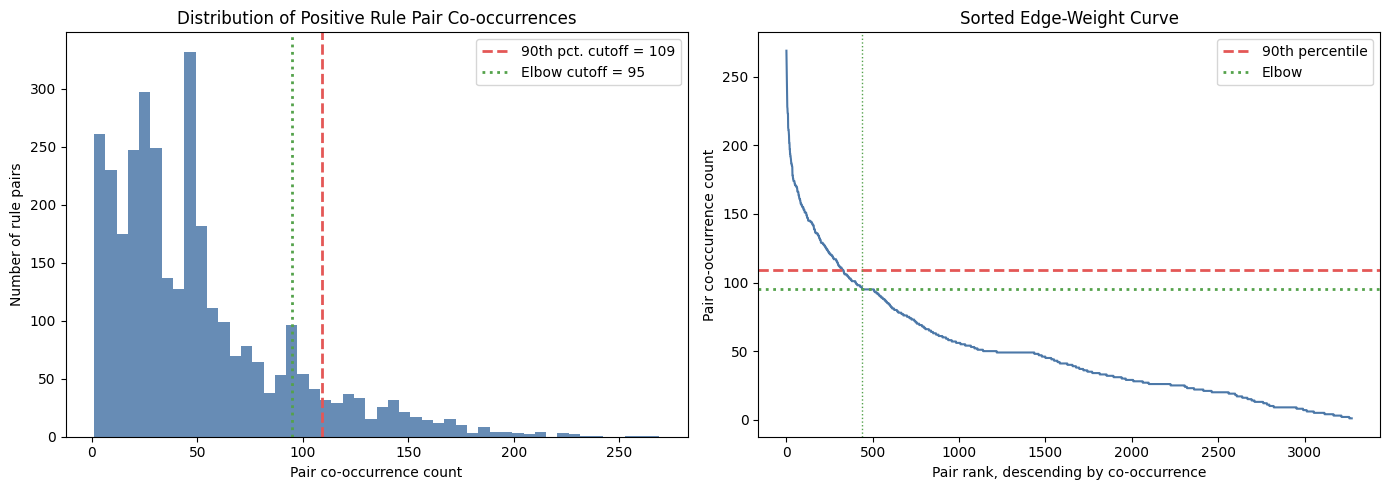

In [67]:
import networkx as nx

positive_pairs = cooccur_long[cooccur_long["cooccur"] > 0].copy()
edge_weights = positive_pairs["cooccur"].astype(float)

edge_weight_summary = edge_weights.describe(percentiles=[
    0.50, 0.75, 0.80, 0.85, 0.90, 0.925, 0.95, 0.975, 0.99
]).to_frame("cooccur")

quantiles = [0.90, 0.925, 0.95, 0.975, 0.99]
cutoff_rows = []

for q in quantiles:
    cutoff = int(np.ceil(edge_weights.quantile(q)))
    network_df_q = positive_pairs[positive_pairs["cooccur"] >= cutoff]

    G_q = nx.Graph()
    for _, row in network_df_q.iterrows():
        G_q.add_edge(row["rule_1"], row["rule_2"], weight=row["cooccur"])

    components = list(nx.connected_components(G_q))
    component_sizes = sorted([len(c) for c in components], reverse=True)

    cutoff_rows.append({
        "quantile": q,
        "cutoff": cutoff,
        "edges": G_q.number_of_edges(),
        "nodes": G_q.number_of_nodes(),
        "components": len(components),
        "largest_component": component_sizes[0] if component_sizes else 0,
        "component_sizes": component_sizes,
    })

cutoff_diagnostics = pd.DataFrame(cutoff_rows)

sorted_weights = edge_weights.sort_values(ascending=False).reset_index(drop=True)
x = np.linspace(0, 1, len(sorted_weights))
y = ((sorted_weights - sorted_weights.min()) / (sorted_weights.max() - sorted_weights.min())).to_numpy()
line = 1 - x
distance_from_endpoint_line = np.abs(y - line) / np.sqrt(2)
distance_from_endpoint_line[0] = 0
distance_from_endpoint_line[-1] = 0
elbow_rank = int(np.argmax(distance_from_endpoint_line)) + 1
elbow_cutoff = int(sorted_weights.iloc[elbow_rank - 1])
elbow_network_df = positive_pairs[positive_pairs["cooccur"] >= elbow_cutoff]

recommended_quantile = 0.90
recommended_cutoff = int(np.ceil(edge_weights.quantile(recommended_quantile)))
recommended_network_df = positive_pairs[positive_pairs["cooccur"] >= recommended_cutoff]

print("Positive rule pairs:", len(positive_pairs))
print("Elbow cutoff:", elbow_cutoff, "| edges:", len(elbow_network_df), "| elbow rank:", elbow_rank)
print("Recommended quantile cutoff:", recommended_cutoff, "| quantile:", recommended_quantile, "| edges:", len(recommended_network_df))

display(edge_weight_summary)
display(cutoff_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(edge_weights, bins=50, color="#4C78A8", alpha=0.85)
axes[0].axvline(recommended_cutoff, color="#E45756", linestyle="--", linewidth=2, label=f"90th pct. cutoff = {recommended_cutoff}")
axes[0].axvline(elbow_cutoff, color="#54A24B", linestyle=":", linewidth=2, label=f"Elbow cutoff = {elbow_cutoff}")
axes[0].set_xlabel("Pair co-occurrence count")
axes[0].set_ylabel("Number of rule pairs")
axes[0].set_title("Distribution of Positive Rule Pair Co-occurrences")
axes[0].legend()

axes[1].plot(np.arange(1, len(sorted_weights) + 1), sorted_weights, color="#4C78A8")
axes[1].axhline(recommended_cutoff, color="#E45756", linestyle="--", linewidth=2, label="90th percentile")
axes[1].axhline(elbow_cutoff, color="#54A24B", linestyle=":", linewidth=2, label="Elbow")
axes[1].axvline(elbow_rank, color="#54A24B", linestyle=":", linewidth=1)
axes[1].set_xlabel("Pair rank, descending by co-occurrence")
axes[1].set_ylabel("Pair co-occurrence count")
axes[1].set_title("Sorted Edge-Weight Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## Cutoff-Based Network


Cutoff: 109
Edges: 331
Nodes: 48
Components: 1
Component sizes: [48]


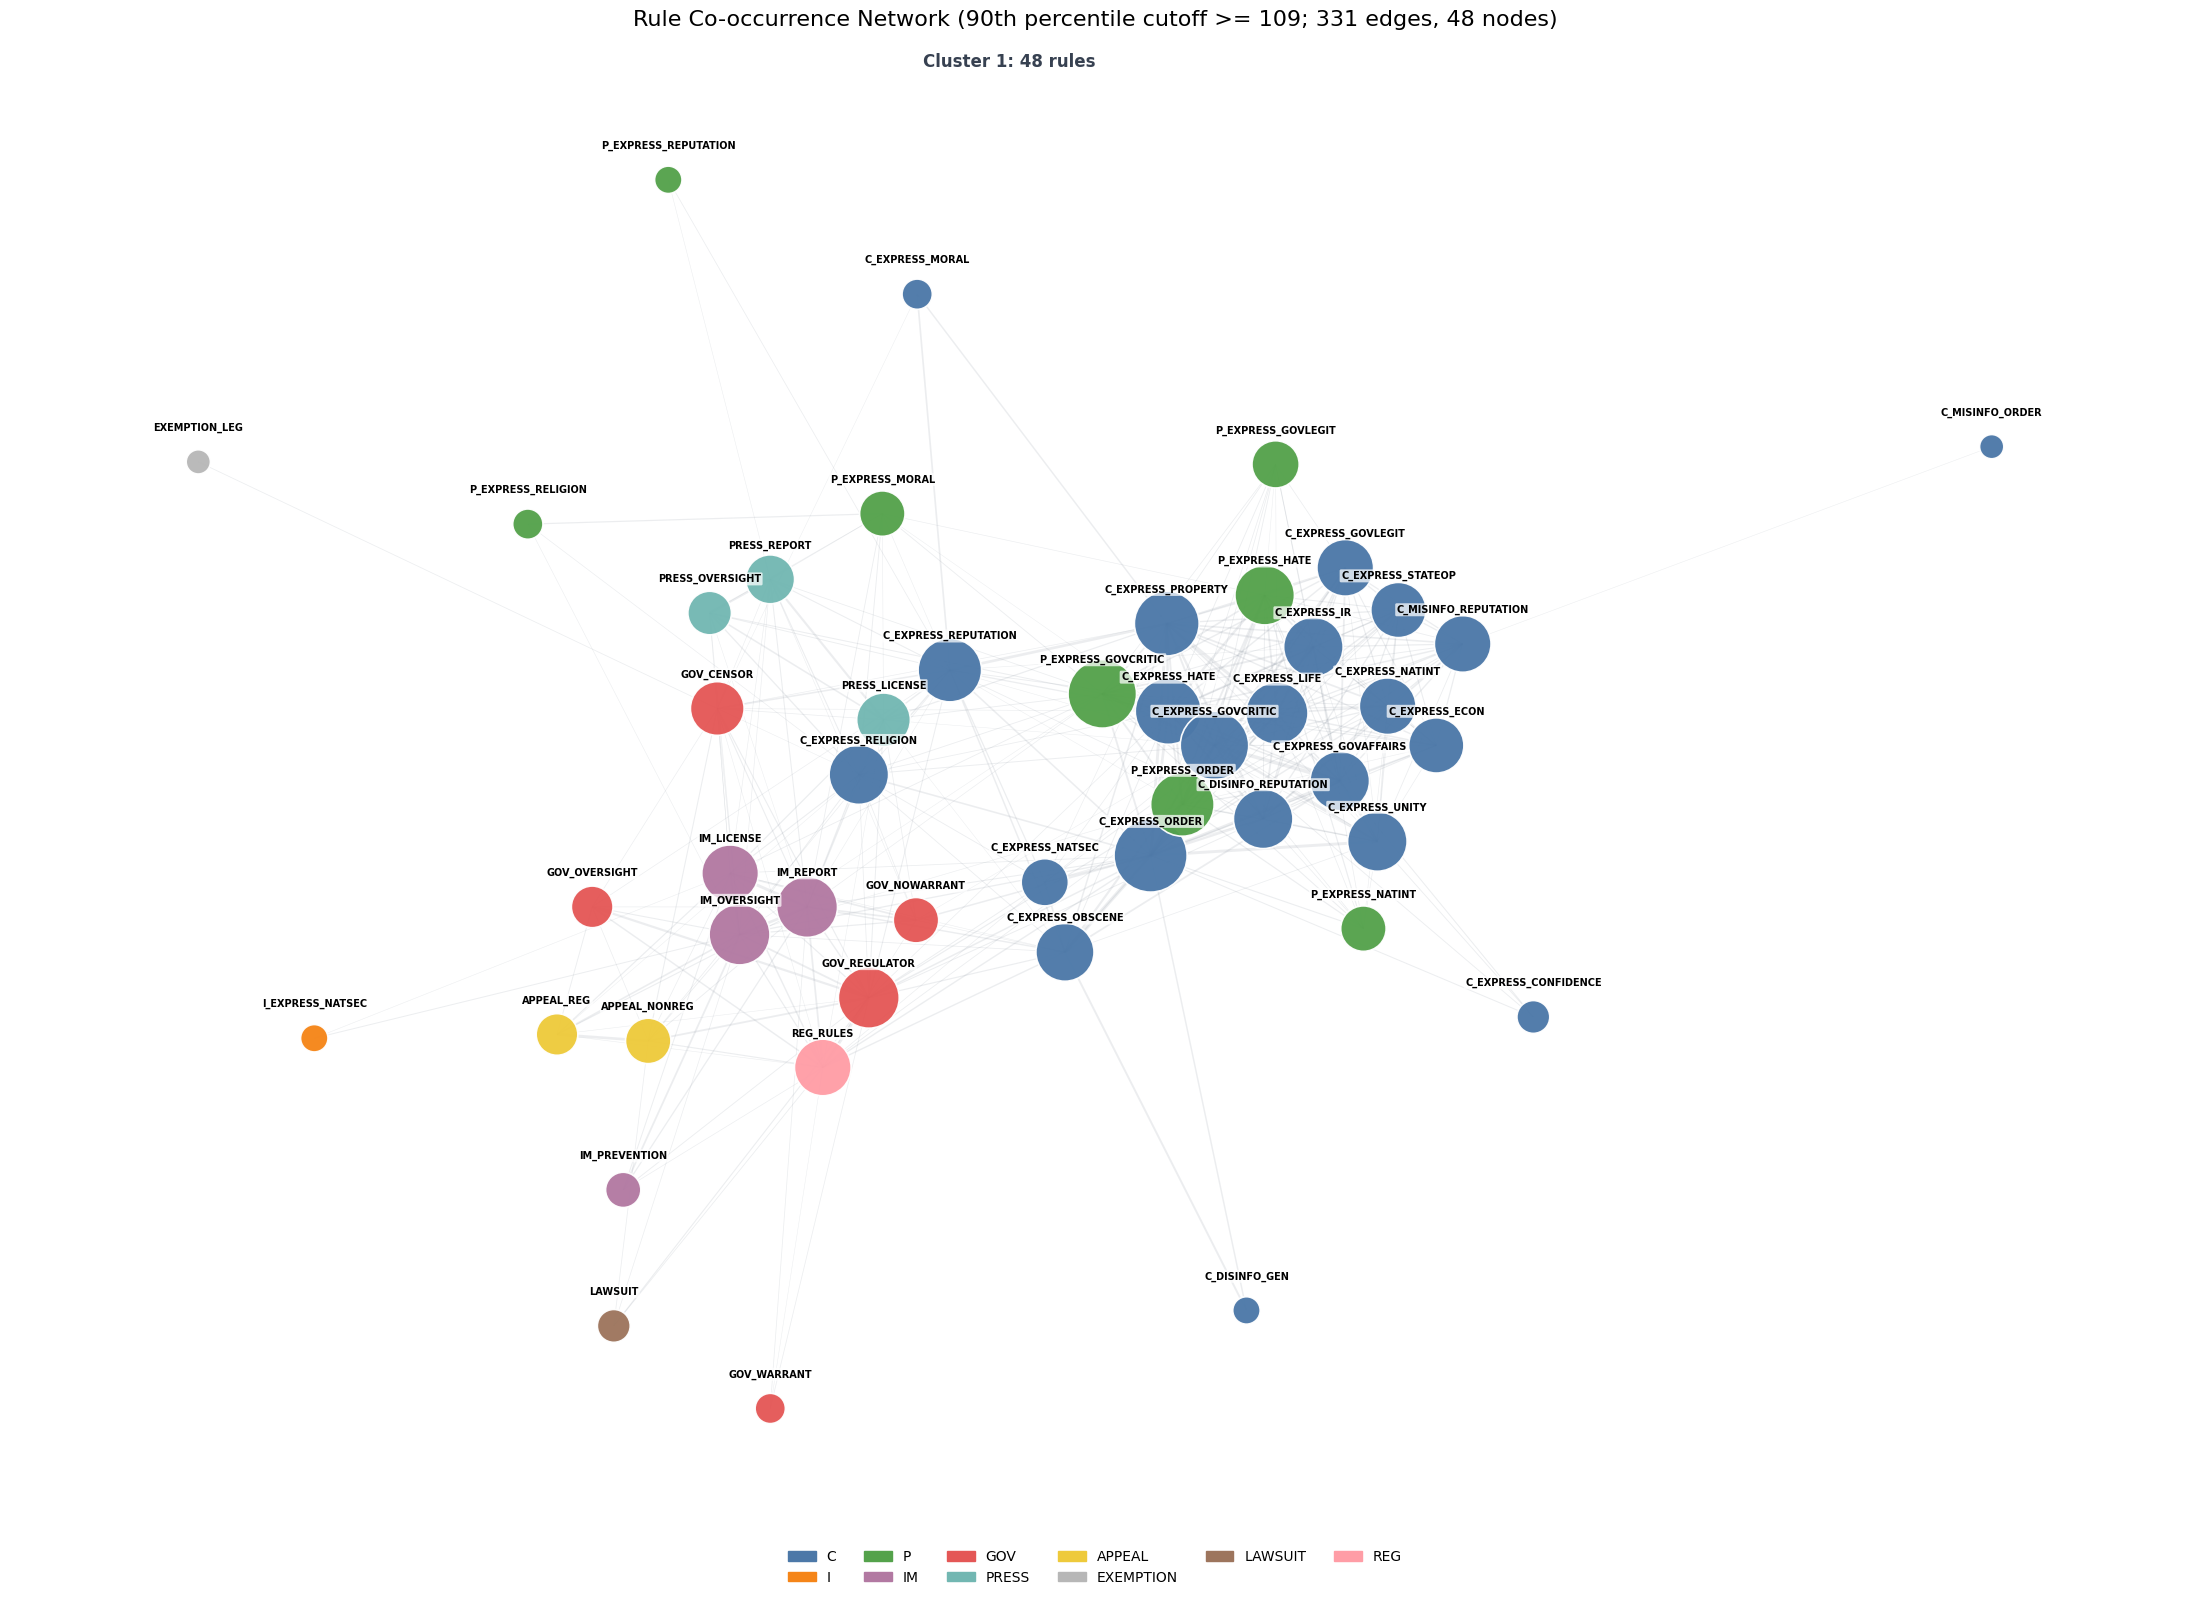

,rule_1,rule_2,cooccur
4873,C_EXPRESS_GOVCRITIC,C_EXPRESS_ORDER,269
2403,C_EXPRESS_OBSCENE,C_EXPRESS_ORDER,260
4706,C_EXPRESS_GOVAFFAIRS,C_EXPRESS_GOVCRITIC,253
4683,C_EXPRESS_GOVAFFAIRS,C_EXPRESS_ORDER,237
1646,C_EXPRESS_LIFE,C_EXPRESS_PROPERTY,232
6914,GOV_REGULATOR,REG_RULES,228
4897,C_EXPRESS_GOVCRITIC,P_EXPRESS_GOVCRITIC,227
2726,C_EXPRESS_ORDER,C_EXPRESS_UNITY,224
2691,C_EXPRESS_ORDER,C_EXPRESS_PROPERTY,223
7970,IM_LICENSE,IM_REPORT,223


In [68]:
import matplotlib.patches as mpatches

layout_spread = 1.75  # Increase toward 2.2 for more spacing; decrease toward 1.2 for tighter clusters.
component_radius = 3.8  # Used when the cutoff produces multiple components.
show_labels = True
label_font_size = 7
label_offset = 0.11
node_size_base = 220
node_size_per_degree = 85

family_colors = {
    "C": "#4C78A8",
    "I": "#F58518",
    "P": "#54A24B",
    "IM": "#B279A2",
    "GOV": "#E45756",
    "PRESS": "#72B7B2",
    "APPEAL": "#EECA3B",
    "EXEMPTION": "#B7B7B7",
    "LAWSUIT": "#9D755D",
    "REG": "#FF9DA6",
}


def plot_cutoff_network(network_cutoff, cutoff_label, *, layout_spread=layout_spread):
    network_df = positive_pairs[positive_pairs["cooccur"] >= network_cutoff].copy()

    G = nx.Graph()
    for _, row in network_df.iterrows():
        G.add_edge(row["rule_1"], row["rule_2"], weight=row["cooccur"])

    components = sorted(nx.connected_components(G), key=len, reverse=True)
    component_sizes = [len(component) for component in components]

    print("Cutoff:", network_cutoff)
    print("Edges:", G.number_of_edges())
    print("Nodes:", G.number_of_nodes())
    print("Components:", len(components))
    print("Component sizes:", component_sizes)

    component_lookup = {
        node: idx
        for idx, component in enumerate(components)
        for node in component
    }

    if len(components) == 1:
        component_centers = {0: np.array([0.0, 0.0])}
    else:
        angles = np.linspace(0, 2 * np.pi, len(components), endpoint=False)
        component_centers = {
            idx: component_radius * np.array([np.cos(angle), np.sin(angle)])
            for idx, angle in enumerate(angles)
        }

    pos = {}
    for idx, component in enumerate(components):
        subgraph = G.subgraph(component)
        local_k = layout_spread / np.sqrt(max(len(component), 2))
        local_pos = nx.spring_layout(
            subgraph,
            seed=42 + idx,
            k=local_k,
            iterations=1000,
            weight="weight",
        )
        scale = layout_spread * (2.1 if len(component) > 20 else 1.15 if len(component) > 5 else 0.75)
        center = component_centers[idx]
        for node, coords in local_pos.items():
            pos[node] = center + scale * np.array(coords)

    edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges()], dtype=float)
    if len(edge_weights) and edge_weights.max() > edge_weights.min():
        edge_widths = 0.35 + 2.45 * (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min())
        edge_alphas = 0.10 + 0.28 * (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min())
    else:
        edge_widths = np.ones(len(edge_weights)) * 1.2
        edge_alphas = np.ones(len(edge_weights)) * 0.35

    edge_width_lookup = {
        frozenset((u, v)): width
        for (u, v), width in zip(G.edges(), edge_widths)
    }
    edge_alpha_lookup = {
        frozenset((u, v)): alpha
        for (u, v), alpha in zip(G.edges(), edge_alphas)
    }

    node_colors = [family_colors.get(node.split("_")[0], "#8C8C8C") for node in G.nodes()]
    node_sizes = [node_size_base + node_size_per_degree * G.degree(node) for node in G.nodes()]

    fig_width = 22 if G.number_of_edges() <= 350 else 28
    fig_height = 16 if G.number_of_edges() <= 350 else 22
    plt.figure(figsize=(fig_width, fig_height))
    ax = plt.gca()

    for idx, component in enumerate(components):
        sub_edges = [
            (u, v)
            for u, v in G.edges()
            if component_lookup[u] == idx and component_lookup[v] == idx
        ]
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=sub_edges,
            width=[edge_width_lookup[frozenset(edge)] for edge in sub_edges],
            alpha=np.mean([edge_alpha_lookup[frozenset(edge)] for edge in sub_edges]) if sub_edges else 0.25,
            edge_color="#8B95A1",
            ax=ax,
        )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="white",
        linewidths=1.2,
        alpha=0.96,
        ax=ax,
    )

    if show_labels:
        label_pos = {
            node: coords + np.array([0.0, label_offset])
            for node, coords in pos.items()
        }

        nx.draw_networkx_labels(
            G,
            label_pos,
            font_size=label_font_size,
            font_weight="semibold",
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.72,
                "boxstyle": "round,pad=0.14",
            },
            ax=ax,
        )

    for idx, component in enumerate(components):
        xs = [pos[node][0] for node in component]
        ys = [pos[node][1] for node in component]
        ax.text(
            np.mean(xs),
            max(ys) + 0.35,
            f"Cluster {idx + 1}: {len(component)} rules",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="#374151",
        )

    legend_handles = [
        mpatches.Patch(color=color, label=family)
        for family, color in family_colors.items()
        if any(node.split("_")[0] == family for node in G.nodes())
    ]

    plt.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        ncol=6,
        frameon=False,
    )
    plt.title(
        f"Rule Co-occurrence Network ({cutoff_label}; {G.number_of_edges()} edges, {G.number_of_nodes()} nodes)",
        fontsize=16,
        pad=18,
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return G, network_df.sort_values("cooccur", ascending=False)

G_recommended, network_df_recommended = plot_cutoff_network(
    recommended_cutoff,
    f"90th percentile cutoff >= {recommended_cutoff}",
)

network_df_recommended.head(30)


## Elbow-Cutoff Network


Cutoff: 95
Edges: 507
Nodes: 56
Components: 1
Component sizes: [56]


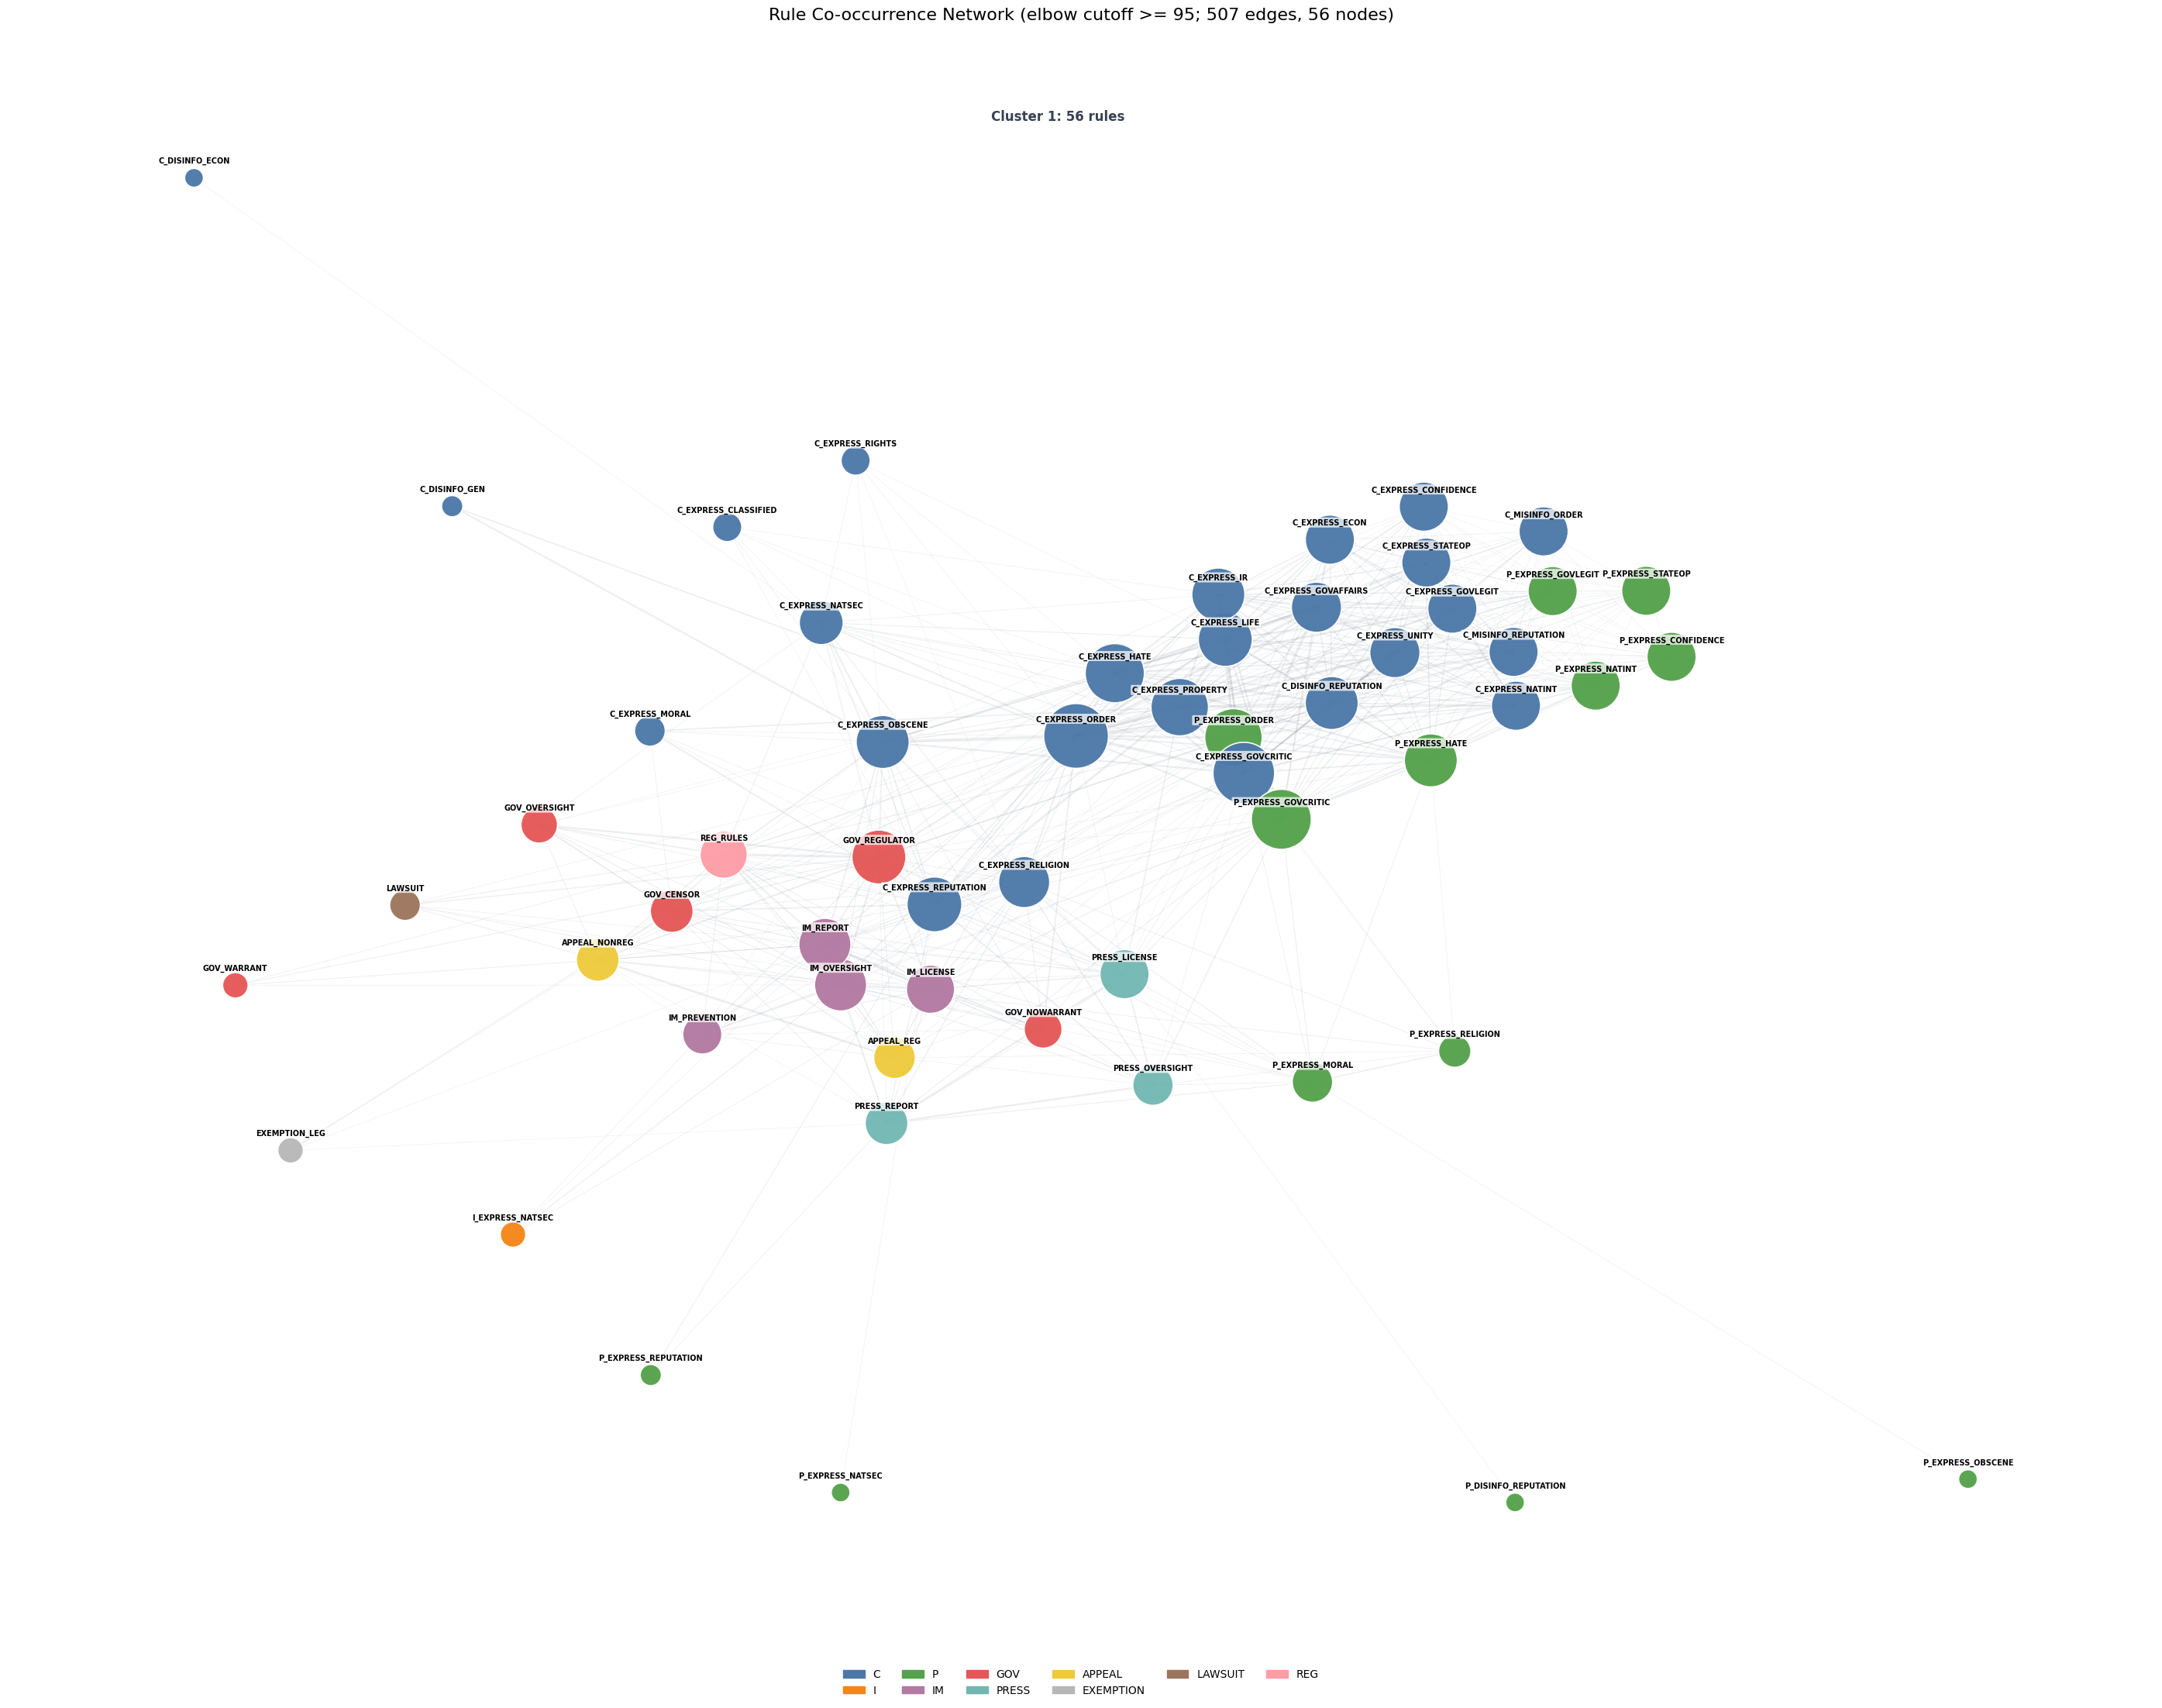

,rule_1,rule_2,cooccur
4873,C_EXPRESS_GOVCRITIC,C_EXPRESS_ORDER,269
2403,C_EXPRESS_OBSCENE,C_EXPRESS_ORDER,260
4706,C_EXPRESS_GOVAFFAIRS,C_EXPRESS_GOVCRITIC,253
4683,C_EXPRESS_GOVAFFAIRS,C_EXPRESS_ORDER,237
1646,C_EXPRESS_LIFE,C_EXPRESS_PROPERTY,232
6914,GOV_REGULATOR,REG_RULES,228
4897,C_EXPRESS_GOVCRITIC,P_EXPRESS_GOVCRITIC,227
2726,C_EXPRESS_ORDER,C_EXPRESS_UNITY,224
2691,C_EXPRESS_ORDER,C_EXPRESS_PROPERTY,223
7970,IM_LICENSE,IM_REPORT,223


In [69]:
G_elbow, network_df_elbow = plot_cutoff_network(
    elbow_cutoff,
    f"elbow cutoff >= {elbow_cutoff}",
    layout_spread=2.05,
)

network_df_elbow.head(30)
